In [1]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
# List of models again
models = ["mobilenetv2", "resnet18", "densenet121", "vgg16", "vit-tiny",
               "efficientnet-b0", "shufflenetv2-0.5x", "regnety-400mf",
               "mnasnet0_5", "convnext-tiny", "ghostnetv2", "tinynet-a"]

linear_metrics = ["accuracy", "precision",  "recall", "auc"]
boxplot_metrics = ["cross_entropy_loss", "mae_loss", "mse_loss"]
barplot_metrics = ["f1_score", "r2_score", "latency", "max_malloc", "size"]

In [13]:
def load_metrics_csv(mode):
    # to store all dfs from the csv files
    dfs = []

    # Load data from all CSVs
    for model in models:
        # Load CSV in individual dataframe
        csv_file = glob.glob(f"metrics/pytorch/{mode}_metrics_{model}_*.csv")[0]
        
        df = pd.read_csv(csv_file)

        # Add the model name as a column 
        df["model"] = model
        
        # Append to the list of dataframes for all models
        dfs.append(df)

    # Concatenate all data into a single DataFrame
    dfs_all = pd.concat(dfs, ignore_index=True)
    
    return dfs_all

def lineplot(metrics, models, df, mode):
    for metric in metrics:
        # Line plot for each metric
        plt.figure(figsize=(10, 5))
        for model in models:
            # Subset for the specific model and group by 'Epoch' to calculate the mean
            subset = df[df["model"] == model].groupby("epoch")[metric].mean()
            
            # Plot the metric
            plt.plot(subset.index, subset.values, label=model,  linestyle='-')
            print(f"Average & Highest {mode.capitalize()} {metric.capitalize()} for {model}: {subset.mean():4f}, {subset.max():4f}")

        plt.xlabel("Epoch")
        plt.ylabel(metric.capitalize())
        plt.title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models in {mode.capitalize()}")
        plt.legend()
        plt.show()

def boxplot(metrics, models, df, mode):
    for metric in metrics:
        fig, axes = plt.subplots(1, 2, figsize=(20, 5))

        # Boxplot with outliers
        sns.boxplot(x="model", y=metric, data=df, order=models, ax=axes[0])
        axes[0].set_title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models in {mode.capitalize()}")
        axes[0].tick_params(axis='x', rotation=45, labelsize=10)

        # Boxplot without outliers
        sns.boxplot(x="model", y=metric, data=df, order=models, showfliers=False, ax=axes[1])
        axes[1].set_title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models (Outliers Removed) in {mode.capitalize()}")
        axes[1].tick_params(axis='x', rotation=45, labelsize=10)

        plt.tight_layout()
        plt.show()

def barplot(metrics, models, df, mode):
    for metric in metrics:
        if (metric == "latency" or metric == "max_malloc") and mode == "training":
            continue
        elif metric == "size" and mode != "testing":
            continue
        else:
            plt.figure(figsize=(10, 5))
            for model in models:
                # Plot the metric
                sns.barplot(x="model", y=metric, data=df, order=models, errorbar="sd")
            plt.xticks(rotation=45, ha='right')
            plt.title(f"{metric.capitalize()} over Epochs Across SOTA-CV Models in {mode.capitalize()}")
            plt.show()

In [14]:
dfs_all_training = load_metrics_csv("training")
dfs_all_validation = load_metrics_csv("validation")
dfs_all_testing = load_metrics_csv("testing")

Average & Highest Training Accuracy for mobilenetv2: 0.665211, 0.801937
Average & Highest Training Accuracy for resnet18: 0.713612, 0.821303
Average & Highest Training Accuracy for densenet121: 0.755751, 0.837148
Average & Highest Training Accuracy for vgg16: 0.650329, 0.838908
Average & Highest Training Accuracy for vit-tiny: 0.644266, 0.830106
Average & Highest Training Accuracy for efficientnet-b0: 0.602212, 0.779930
Average & Highest Training Accuracy for shufflenetv2-0.5x: 0.528028, 0.634683
Average & Highest Training Accuracy for regnety-400mf: 0.709299, 0.824824
Average & Highest Training Accuracy for mnasnet0_5: 0.595305, 0.743398
Average & Highest Training Accuracy for convnext-tiny: 0.463131, 0.623239
Average & Highest Training Accuracy for ghostnetv2: 0.647186, 0.792694
Average & Highest Training Accuracy for tinynet-a: 0.638548, 0.816901


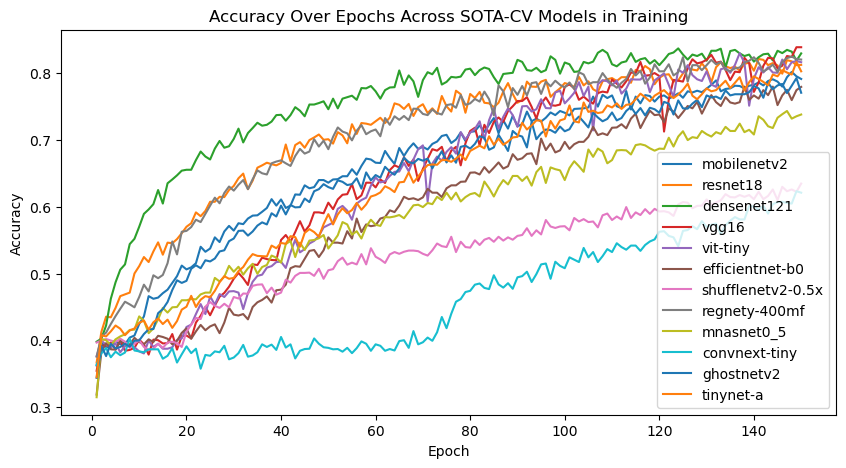

Average & Highest Training Precision for mobilenetv2: 0.638363, 0.801362
Average & Highest Training Precision for resnet18: 0.699227, 0.820213
Average & Highest Training Precision for densenet121: 0.745342, 0.839469
Average & Highest Training Precision for vgg16: 0.608709, 0.838342
Average & Highest Training Precision for vit-tiny: 0.604357, 0.829882
Average & Highest Training Precision for efficientnet-b0: 0.545422, 0.776861
Average & Highest Training Precision for shufflenetv2-0.5x: 0.453950, 0.620279
Average & Highest Training Precision for regnety-400mf: 0.692996, 0.823194
Average & Highest Training Precision for mnasnet0_5: 0.558498, 0.735105
Average & Highest Training Precision for convnext-tiny: 0.399877, 0.623391
Average & Highest Training Precision for ghostnetv2: 0.607540, 0.788715
Average & Highest Training Precision for tinynet-a: 0.600798, 0.815584


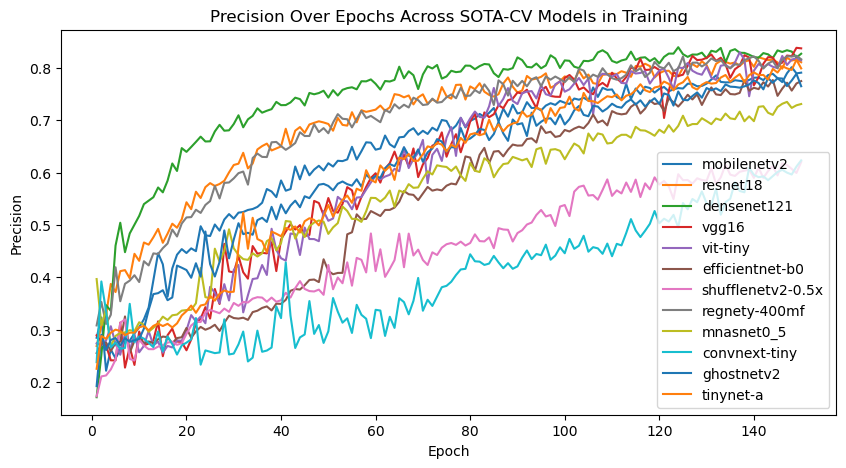

Average & Highest Training Recall for mobilenetv2: 0.665211, 0.801937
Average & Highest Training Recall for resnet18: 0.713612, 0.821303
Average & Highest Training Recall for densenet121: 0.755751, 0.837148
Average & Highest Training Recall for vgg16: 0.650329, 0.838908
Average & Highest Training Recall for vit-tiny: 0.644266, 0.830106
Average & Highest Training Recall for efficientnet-b0: 0.602212, 0.779930
Average & Highest Training Recall for shufflenetv2-0.5x: 0.528028, 0.634683
Average & Highest Training Recall for regnety-400mf: 0.709299, 0.824824
Average & Highest Training Recall for mnasnet0_5: 0.595305, 0.743398
Average & Highest Training Recall for convnext-tiny: 0.463131, 0.623239
Average & Highest Training Recall for ghostnetv2: 0.647186, 0.792694
Average & Highest Training Recall for tinynet-a: 0.638548, 0.816901


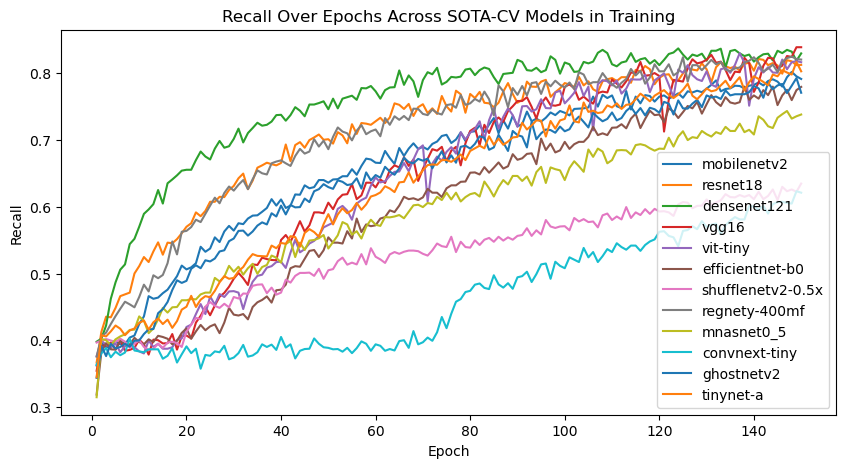

Average & Highest Training Auc for mobilenetv2: 0.834292, 0.941429
Average & Highest Training Auc for resnet18: 0.881238, 0.953756
Average & Highest Training Auc for densenet121: 0.909106, 0.961133
Average & Highest Training Auc for vgg16: 0.801446, 0.959806
Average & Highest Training Auc for vit-tiny: 0.795582, 0.956481
Average & Highest Training Auc for efficientnet-b0: 0.766498, 0.933989
Average & Highest Training Auc for shufflenetv2-0.5x: 0.699166, 0.837015
Average & Highest Training Auc for regnety-400mf: 0.873081, 0.956454
Average & Highest Training Auc for mnasnet0_5: 0.774380, 0.908689
Average & Highest Training Auc for convnext-tiny: 0.627989, 0.818109
Average & Highest Training Auc for ghostnetv2: 0.807851, 0.935527
Average & Highest Training Auc for tinynet-a: 0.807706, 0.946595


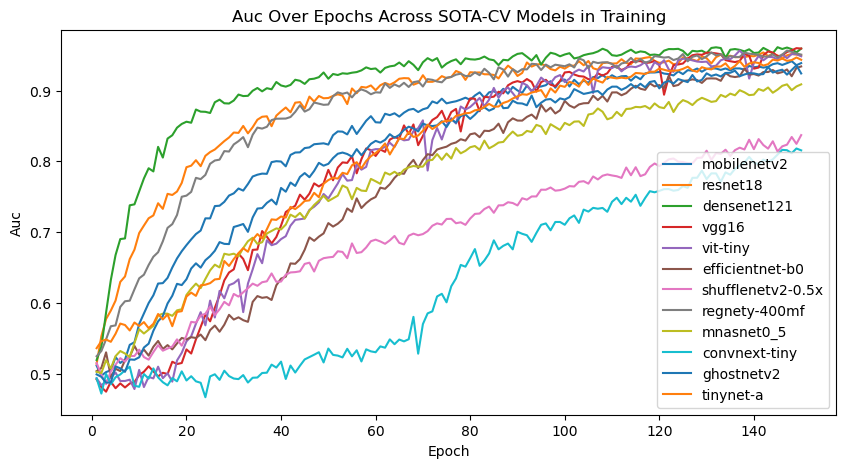

In [15]:
lineplot(linear_metrics, models, dfs_all_training, "training")

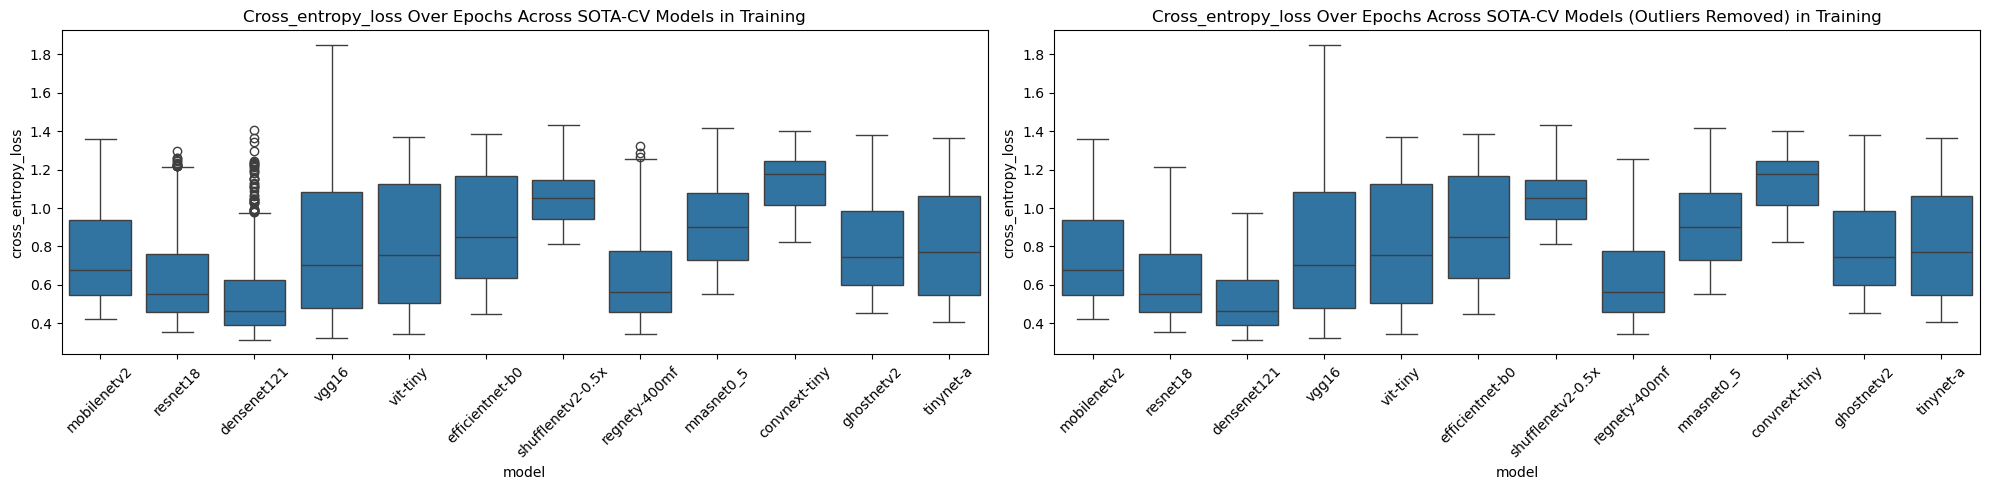

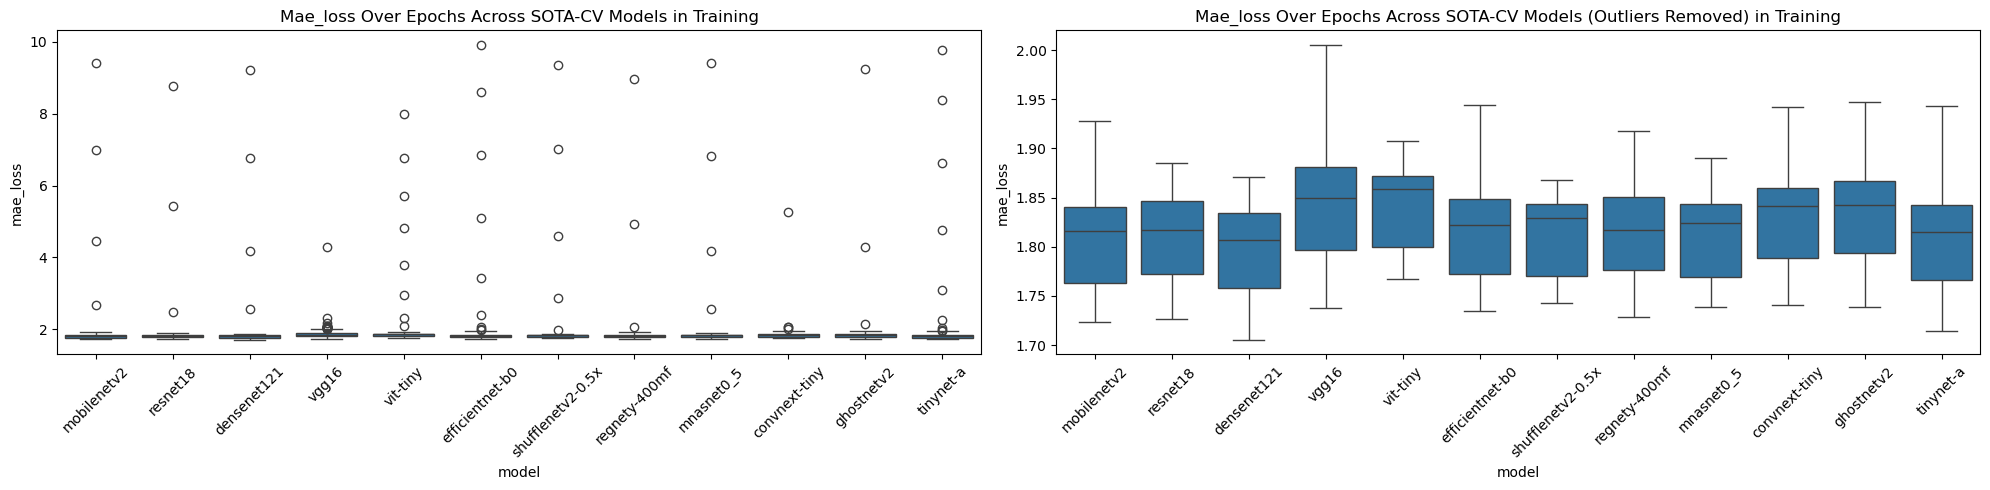

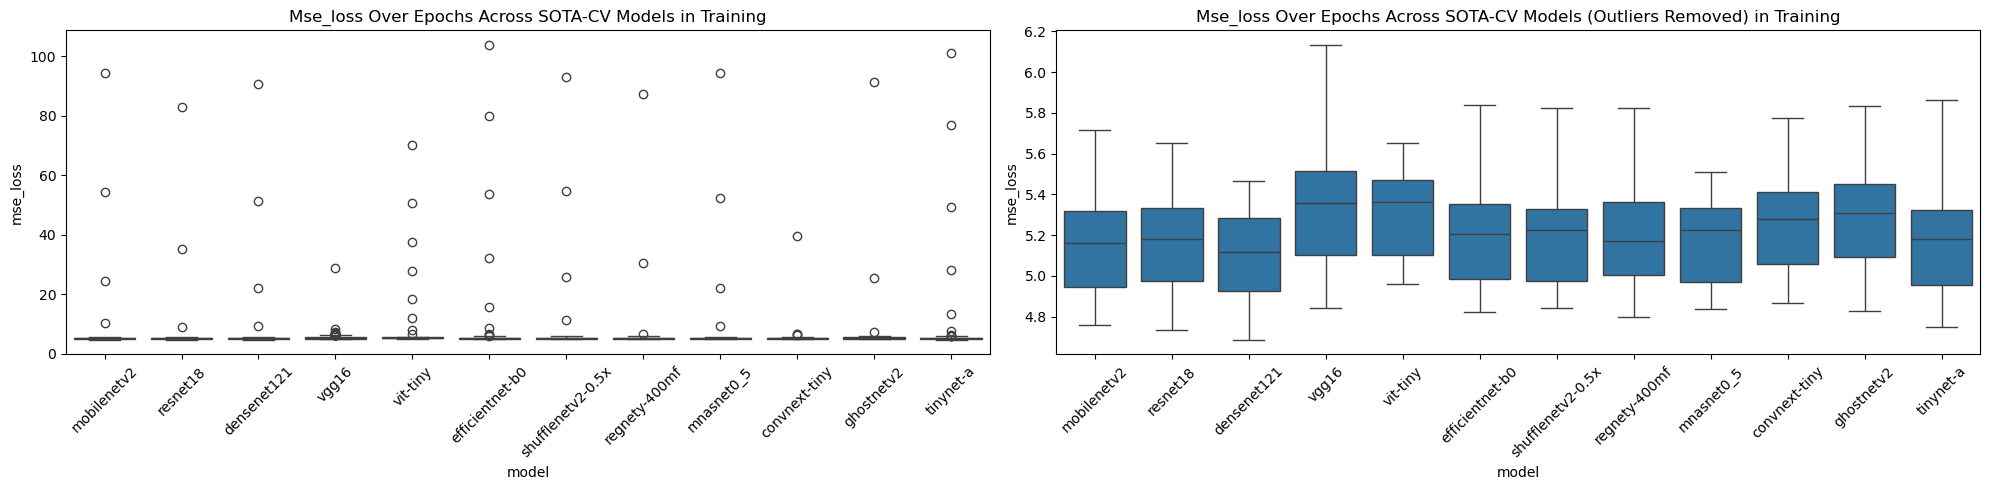

In [16]:
boxplot(boxplot_metrics, models, dfs_all_training, "training")

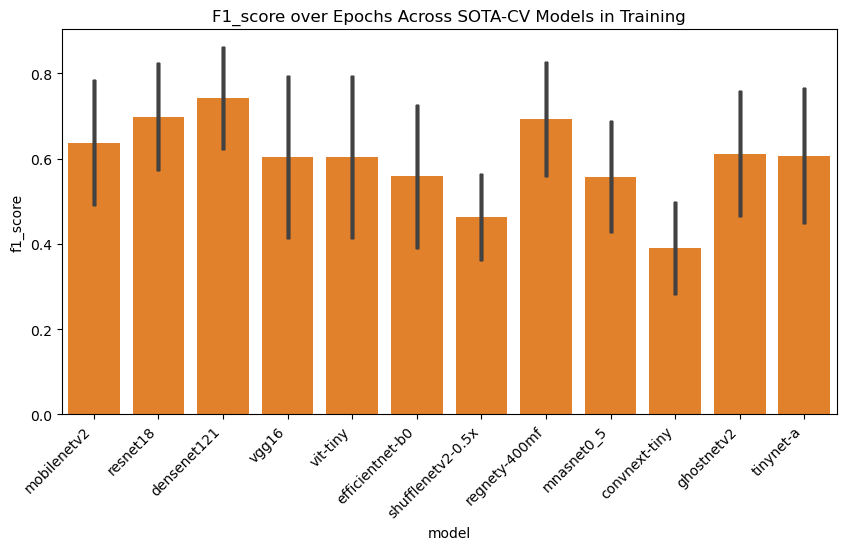

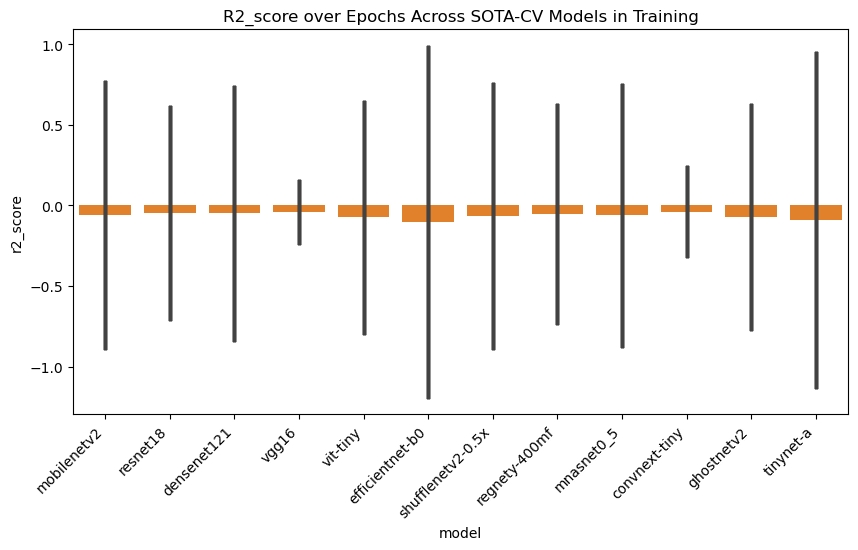

In [17]:
barplot(barplot_metrics, models, dfs_all_training, "training")

Average & Highest Validation Accuracy for mobilenetv2: 0.634038, 0.852113
Average & Highest Validation Accuracy for resnet18: 0.743380, 0.873239
Average & Highest Validation Accuracy for densenet121: 0.792113, 0.887324
Average & Highest Validation Accuracy for vgg16: 0.654038, 0.866197
Average & Highest Validation Accuracy for vit-tiny: 0.655305, 0.845070
Average & Highest Validation Accuracy for efficientnet-b0: 0.631362, 0.830986
Average & Highest Validation Accuracy for shufflenetv2-0.5x: 0.551502, 0.690141
Average & Highest Validation Accuracy for regnety-400mf: 0.699624, 0.852113
Average & Highest Validation Accuracy for mnasnet0_5: 0.320188, 0.387324
Average & Highest Validation Accuracy for convnext-tiny: 0.474366, 0.683099
Average & Highest Validation Accuracy for ghostnetv2: 0.673052, 0.830986
Average & Highest Validation Accuracy for tinynet-a: 0.680704, 0.880282


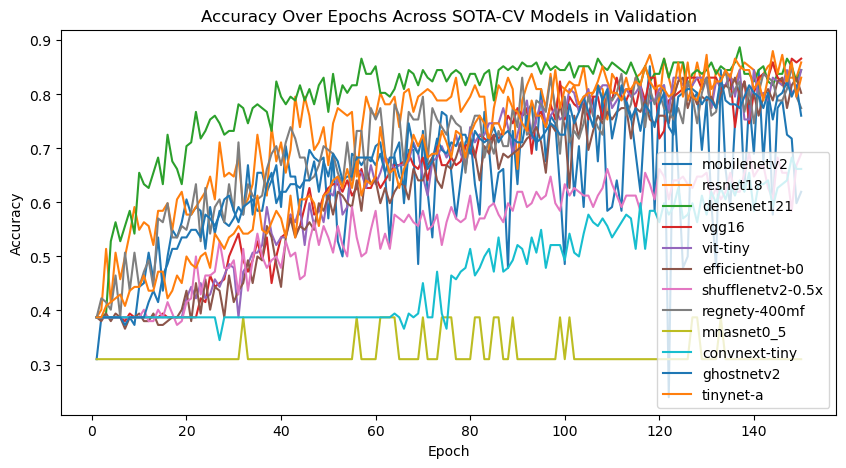

Average & Highest Validation Precision for mobilenetv2: 0.660402, 0.867077
Average & Highest Validation Precision for resnet18: 0.738783, 0.881669
Average & Highest Validation Precision for densenet121: 0.785618, 0.905303
Average & Highest Validation Precision for vgg16: 0.607344, 0.873775
Average & Highest Validation Precision for vit-tiny: 0.594040, 0.854252
Average & Highest Validation Precision for efficientnet-b0: 0.577103, 0.832663
Average & Highest Validation Precision for shufflenetv2-0.5x: 0.474914, 0.721524
Average & Highest Validation Precision for regnety-400mf: 0.694101, 0.847703
Average & Highest Validation Precision for mnasnet0_5: 0.103214, 0.150020
Average & Highest Validation Precision for convnext-tiny: 0.326327, 0.701330
Average & Highest Validation Precision for ghostnetv2: 0.620325, 0.836709
Average & Highest Validation Precision for tinynet-a: 0.634517, 0.880055


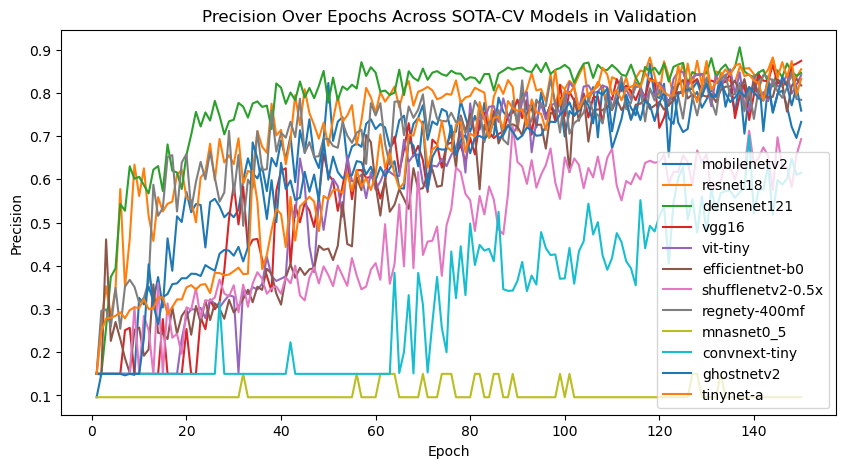

Average & Highest Validation Recall for mobilenetv2: 0.634038, 0.852113
Average & Highest Validation Recall for resnet18: 0.743380, 0.873239
Average & Highest Validation Recall for densenet121: 0.792113, 0.887324
Average & Highest Validation Recall for vgg16: 0.654038, 0.866197
Average & Highest Validation Recall for vit-tiny: 0.655305, 0.845070
Average & Highest Validation Recall for efficientnet-b0: 0.631362, 0.830986
Average & Highest Validation Recall for shufflenetv2-0.5x: 0.551502, 0.690141
Average & Highest Validation Recall for regnety-400mf: 0.699624, 0.852113
Average & Highest Validation Recall for mnasnet0_5: 0.320188, 0.387324
Average & Highest Validation Recall for convnext-tiny: 0.474366, 0.683099
Average & Highest Validation Recall for ghostnetv2: 0.673052, 0.830986
Average & Highest Validation Recall for tinynet-a: 0.680704, 0.880282


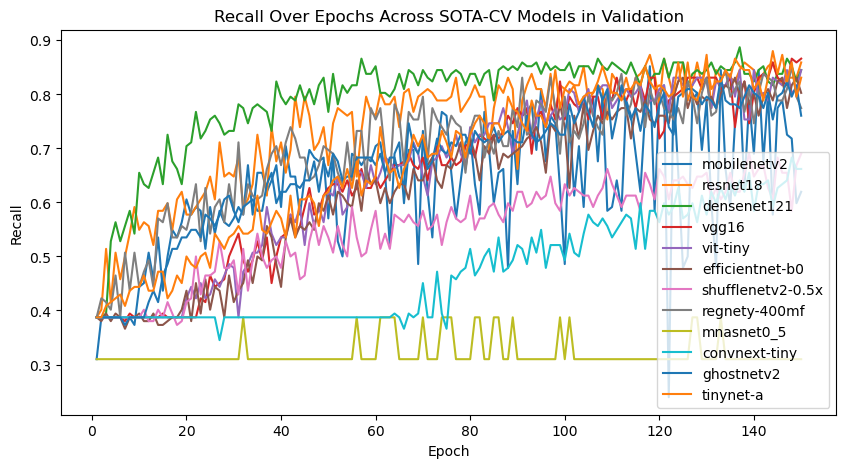

Average & Highest Validation Auc for mobilenetv2: 0.838441, 0.956955
Average & Highest Validation Auc for resnet18: 0.897289, 0.964111
Average & Highest Validation Auc for densenet121: 0.928156, 0.973152
Average & Highest Validation Auc for vgg16: 0.821464, 0.967842
Average & Highest Validation Auc for vit-tiny: 0.824350, 0.962089
Average & Highest Validation Auc for efficientnet-b0: 0.806166, 0.955135
Average & Highest Validation Auc for shufflenetv2-0.5x: 0.745280, 0.861509
Average & Highest Validation Auc for regnety-400mf: 0.867609, 0.963020
Average & Highest Validation Auc for mnasnet0_5: 0.474495, 0.572268
Average & Highest Validation Auc for convnext-tiny: 0.678541, 0.840212
Average & Highest Validation Auc for ghostnetv2: 0.842385, 0.952316
Average & Highest Validation Auc for tinynet-a: 0.841878, 0.971085


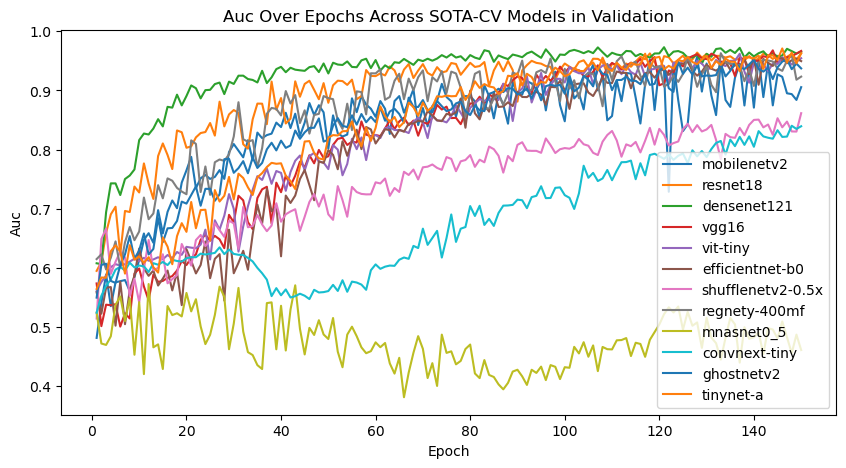

In [18]:
lineplot(linear_metrics, models, dfs_all_validation, "validation")

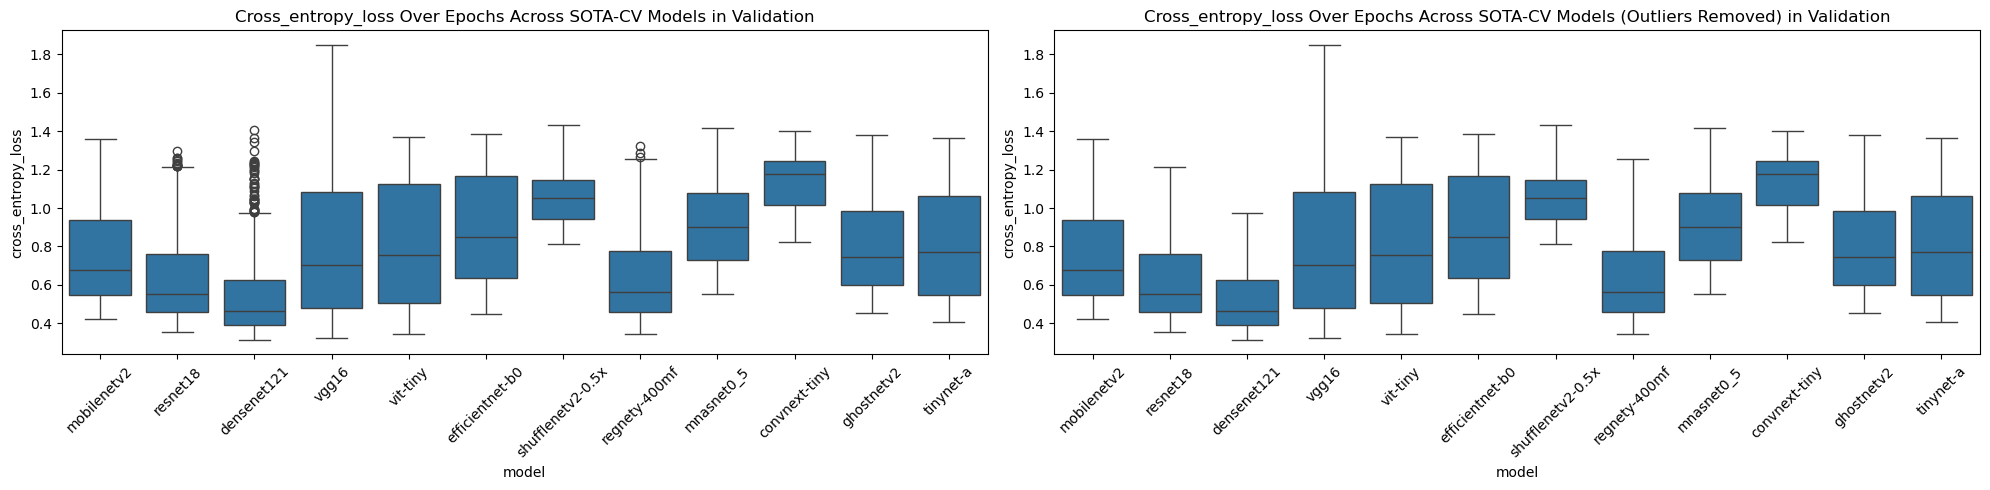

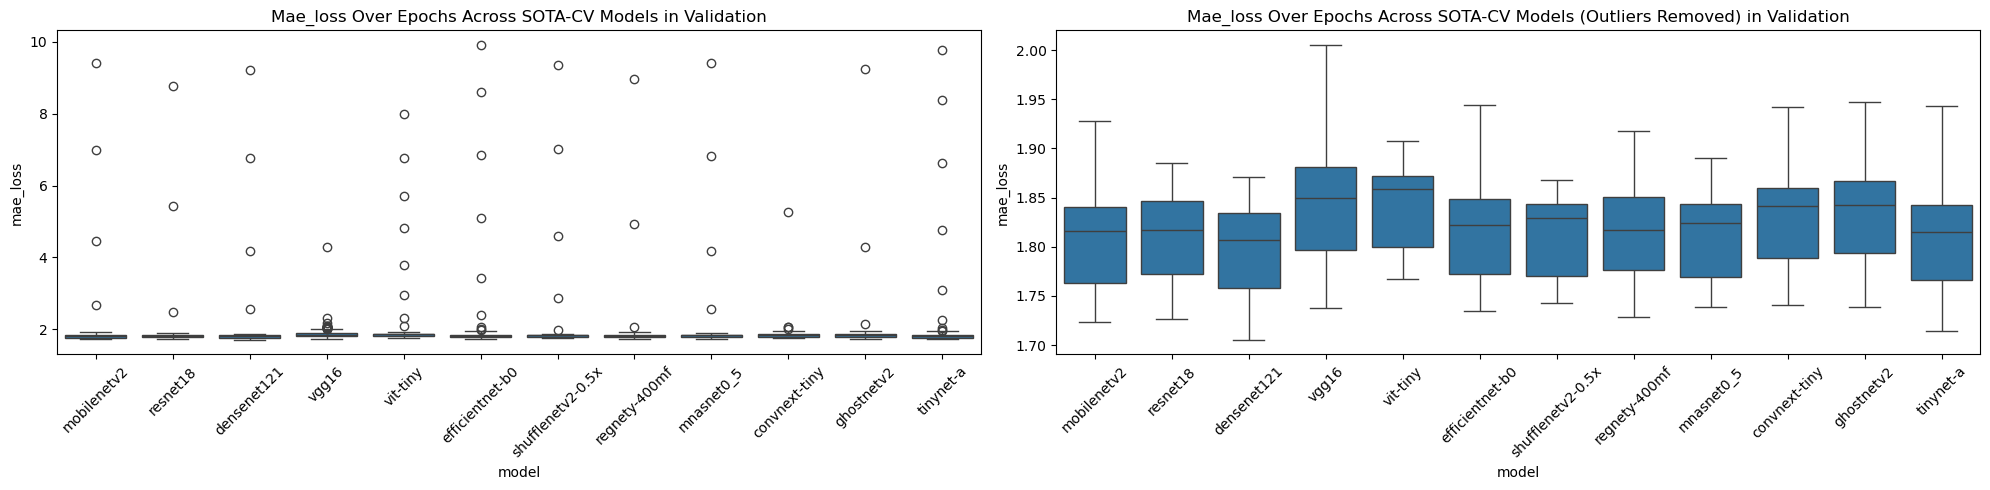

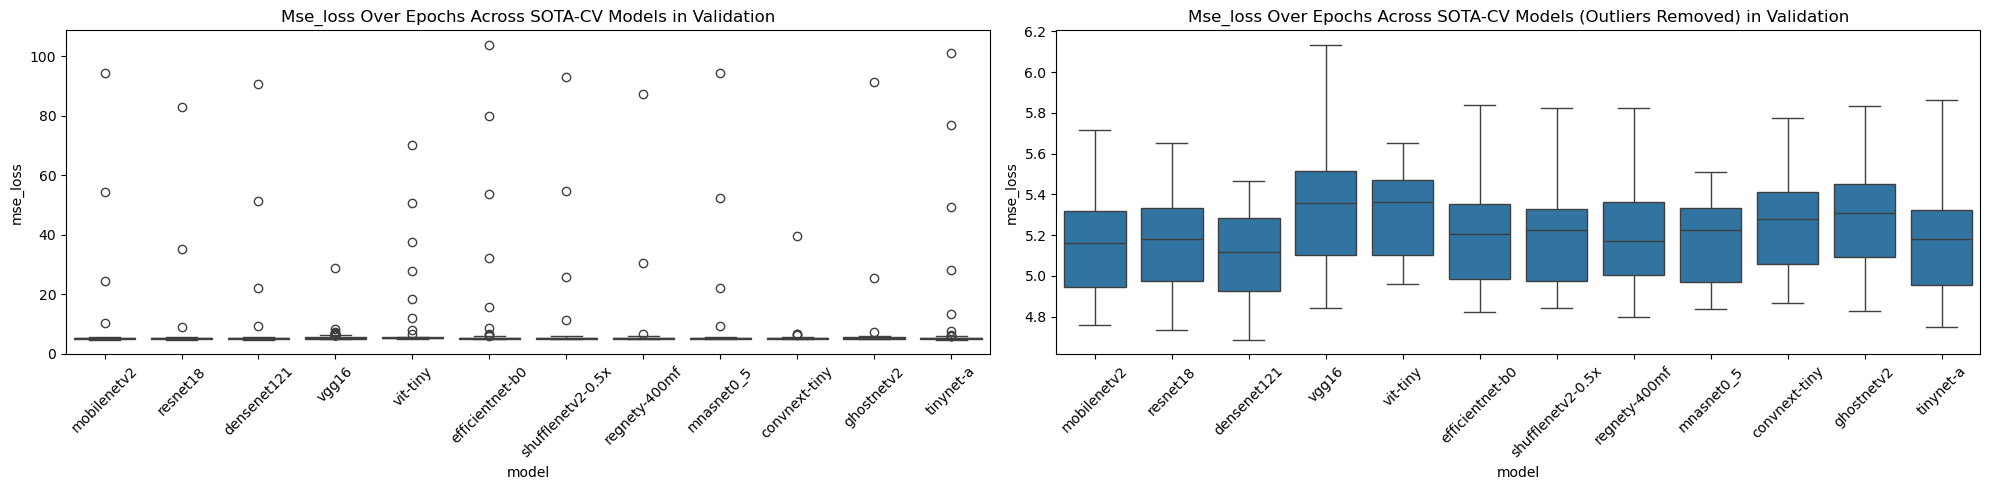

In [19]:
boxplot(boxplot_metrics, models, dfs_all_training, "validation")

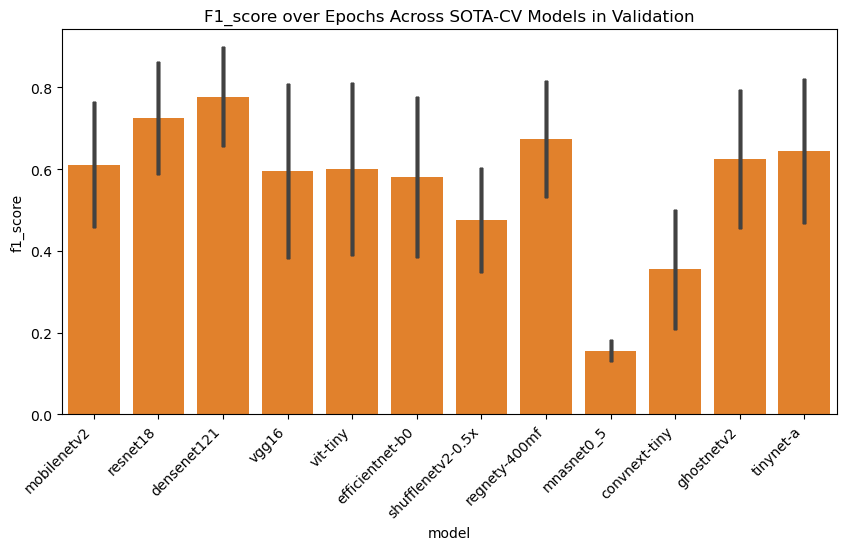

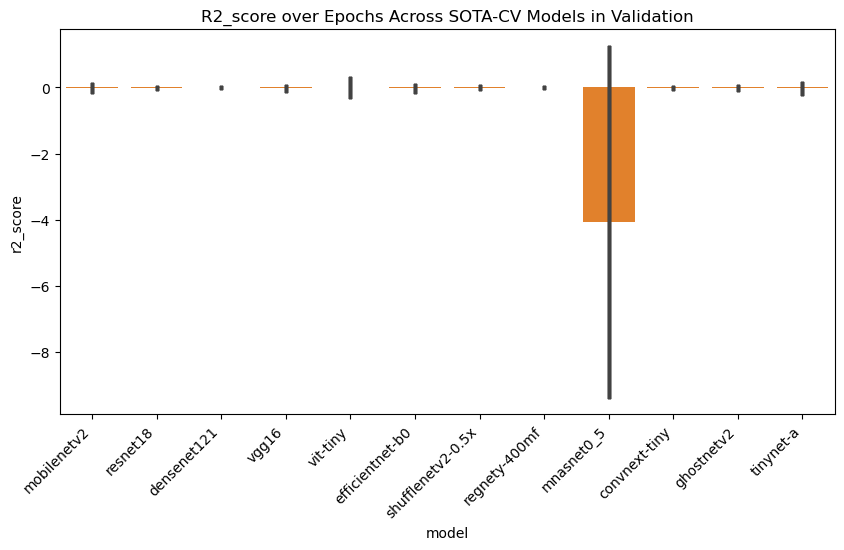

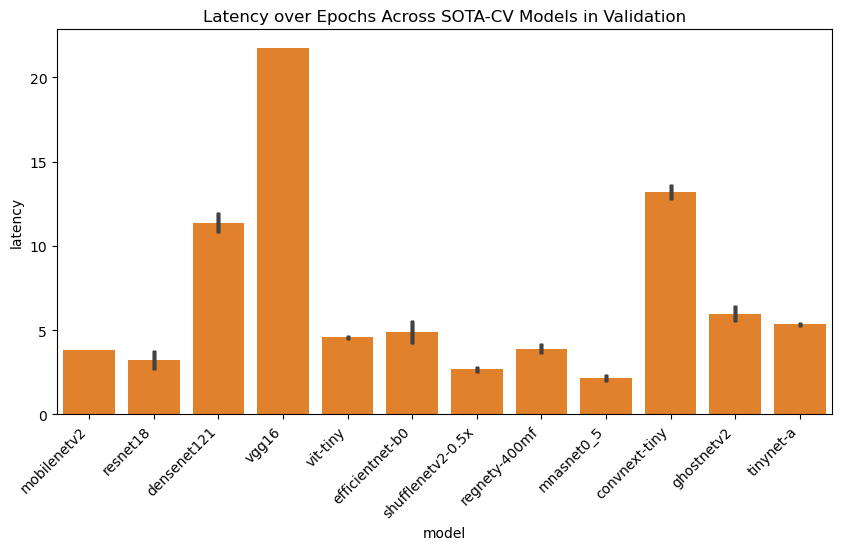

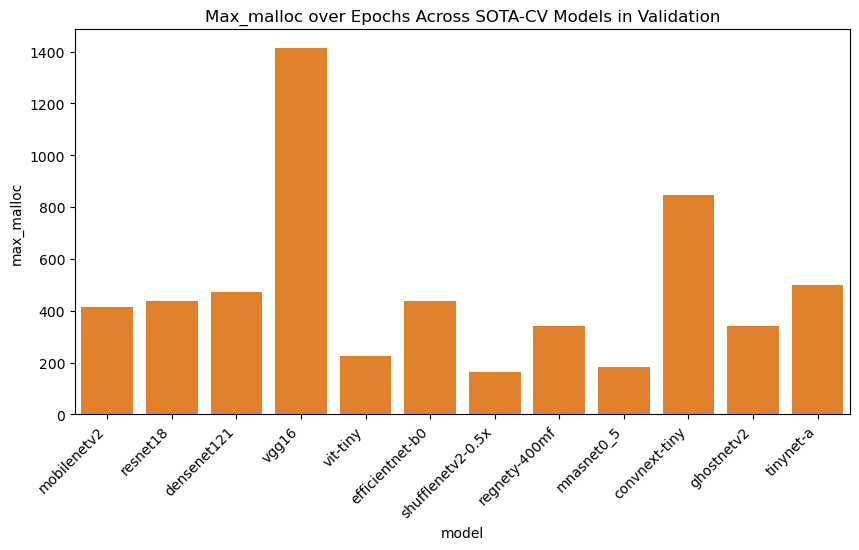

In [20]:
barplot(barplot_metrics, models, dfs_all_validation, "validation")

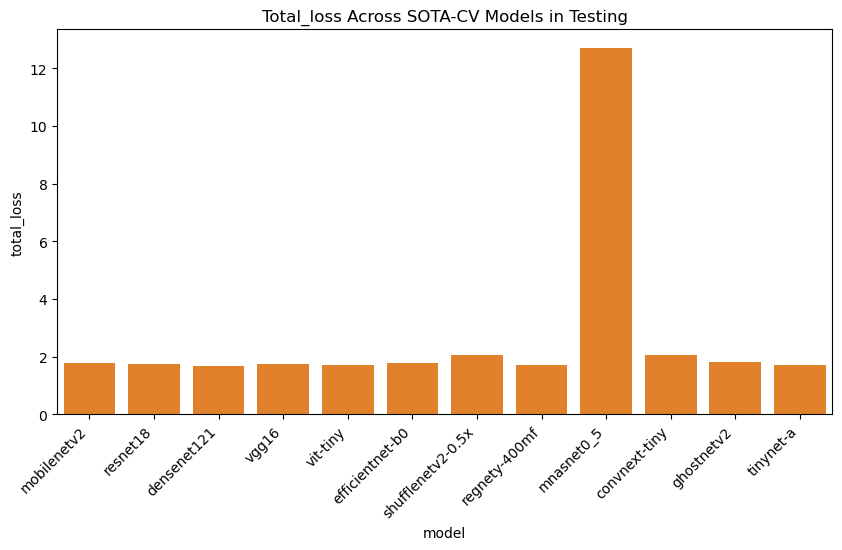

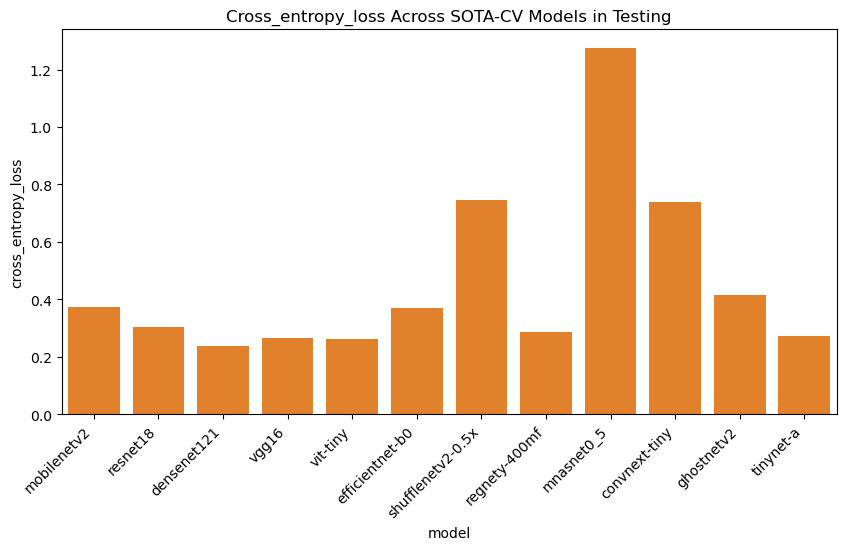

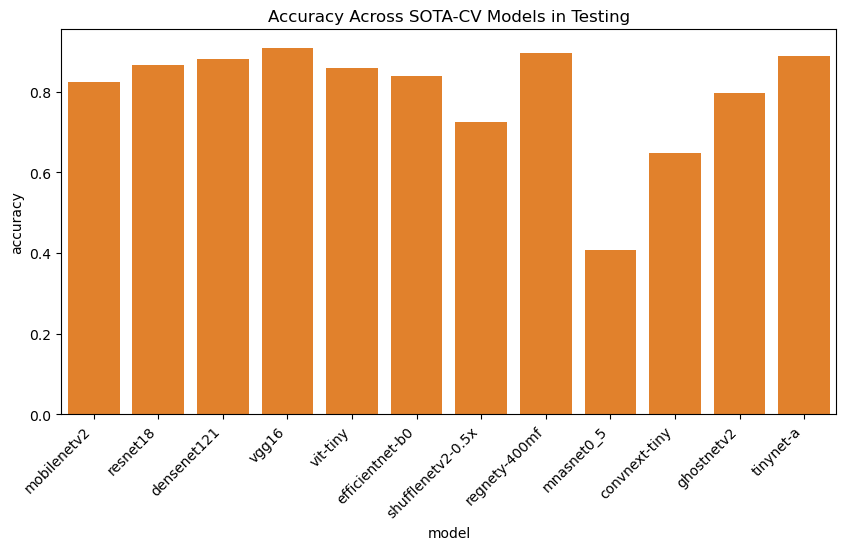

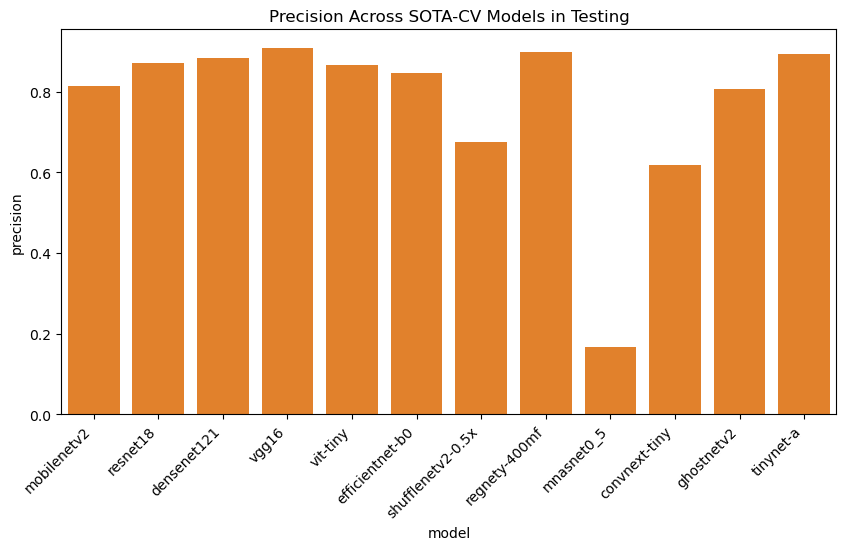

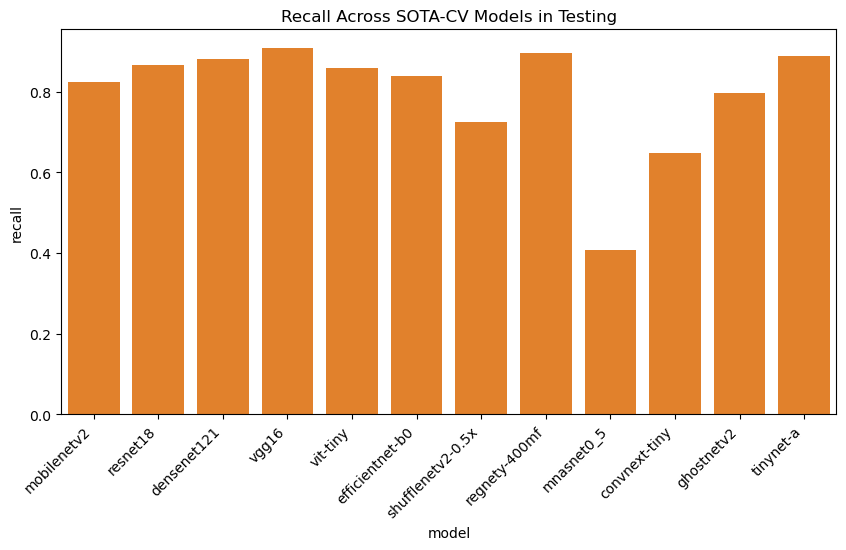

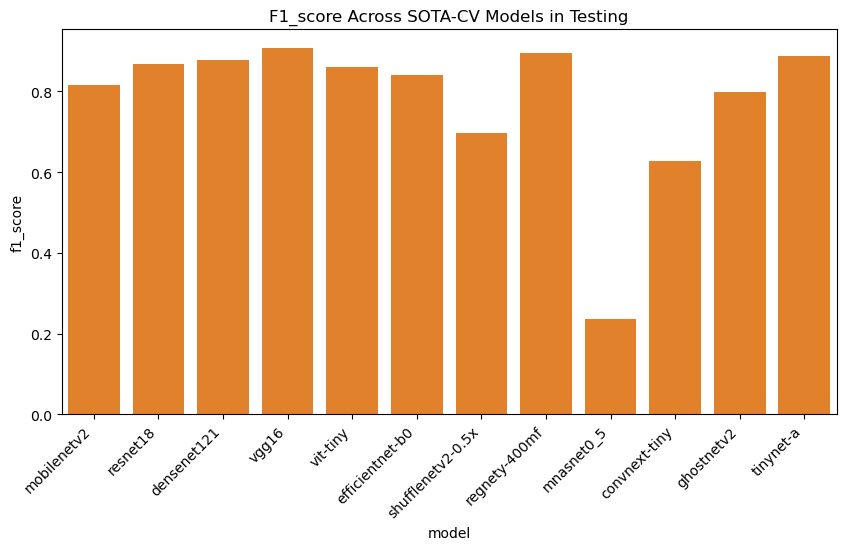

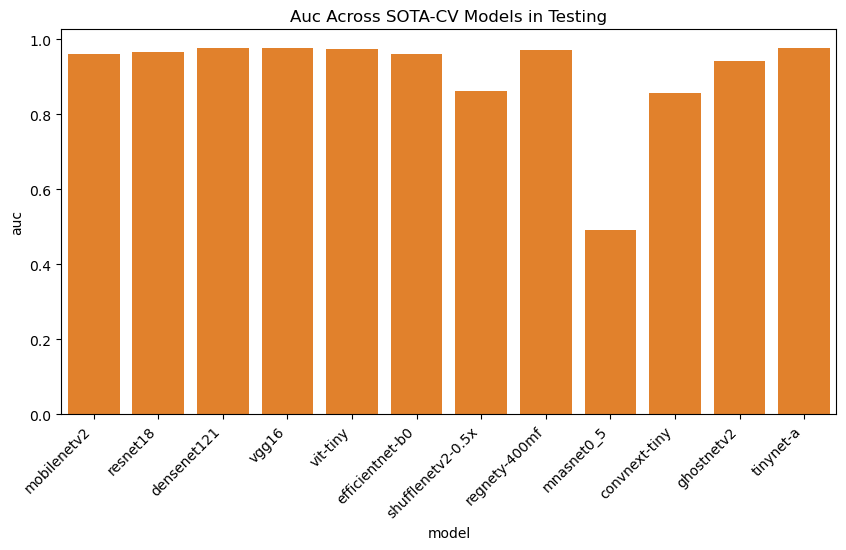

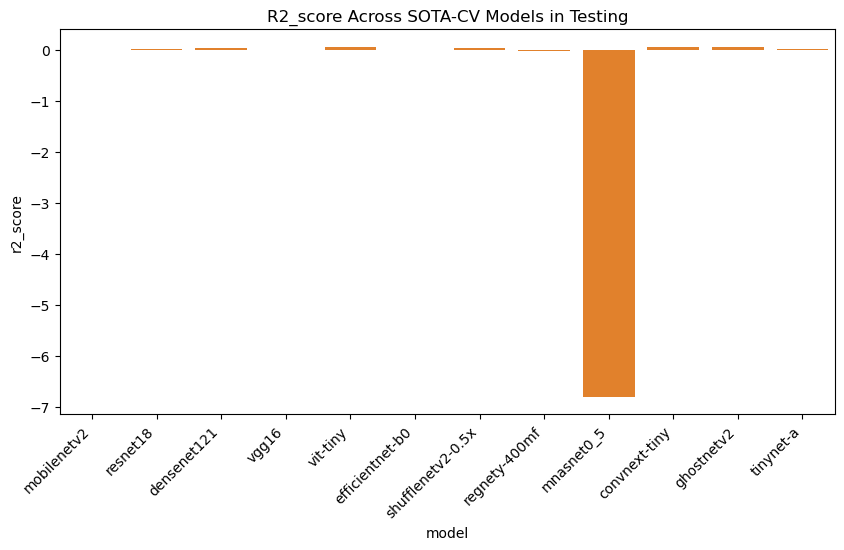

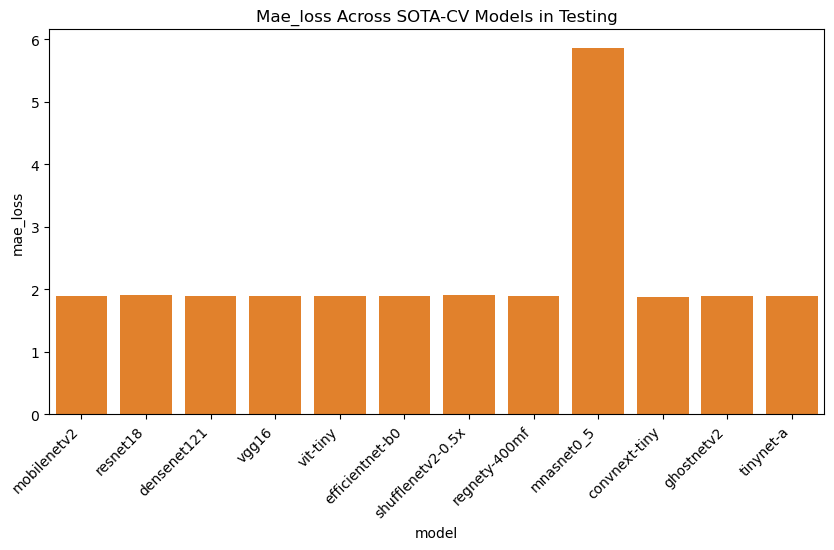

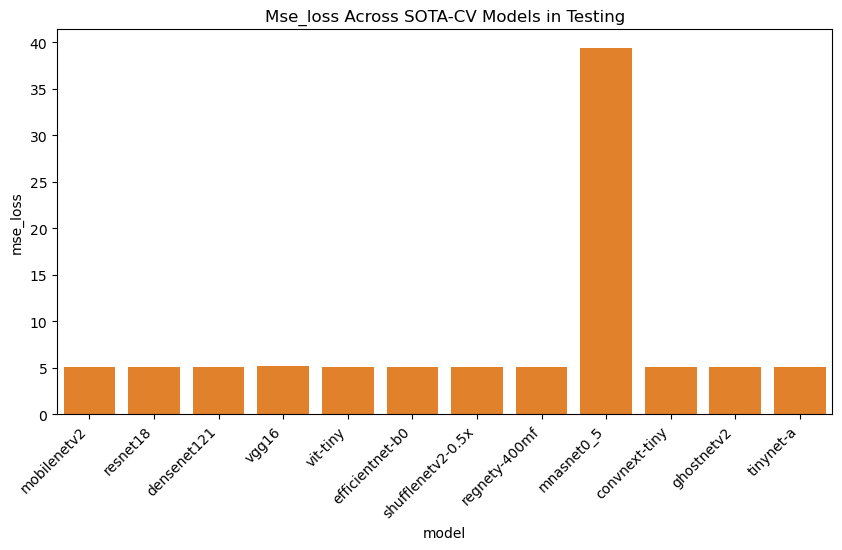

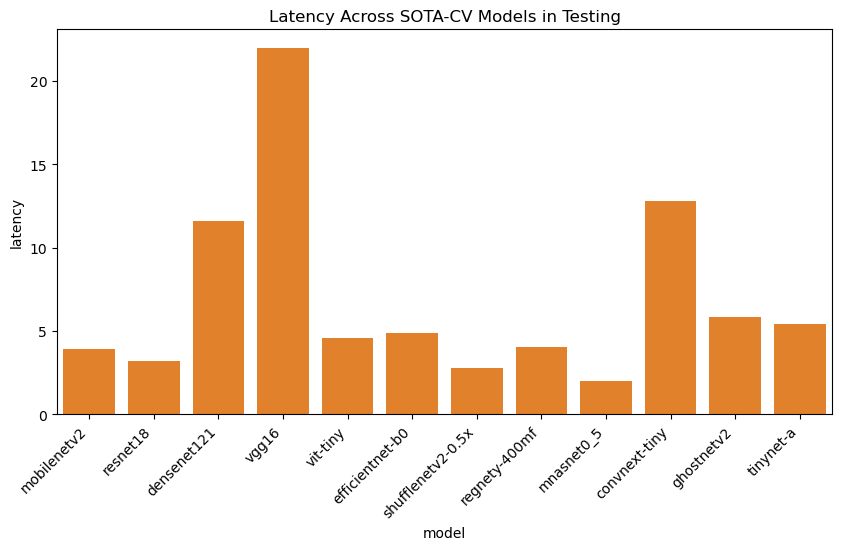

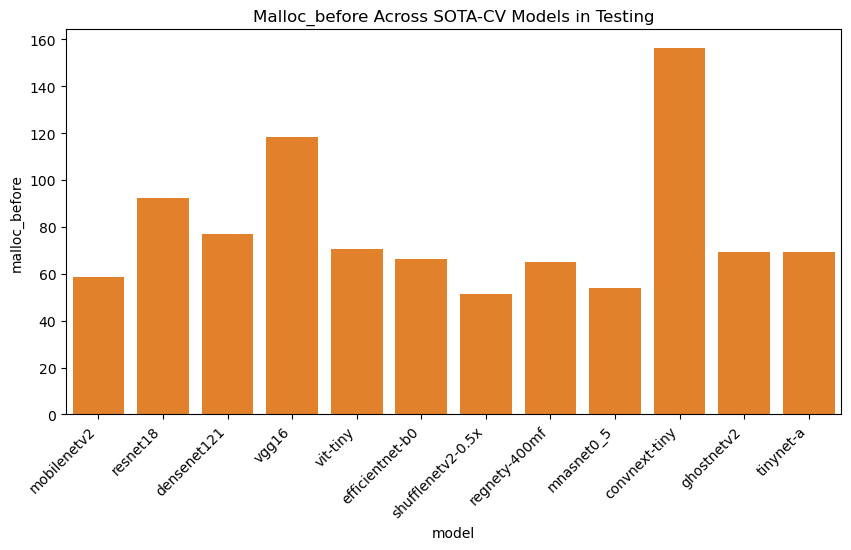

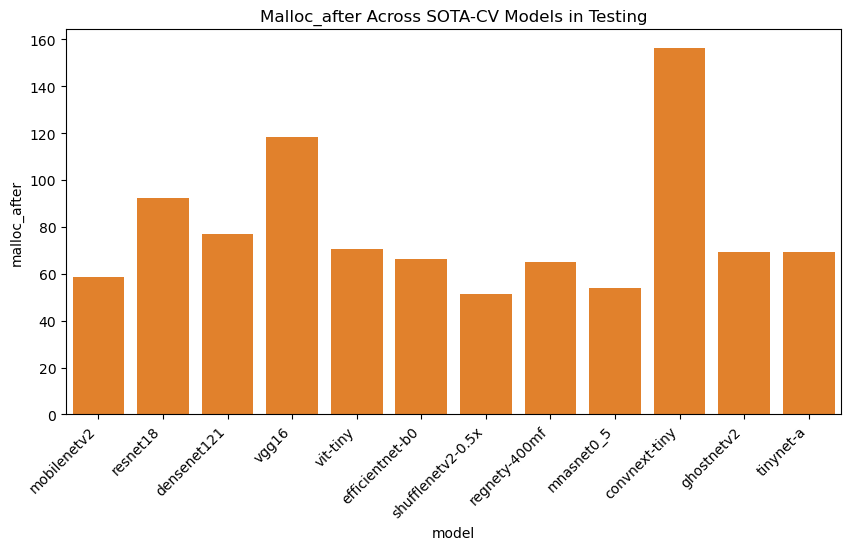

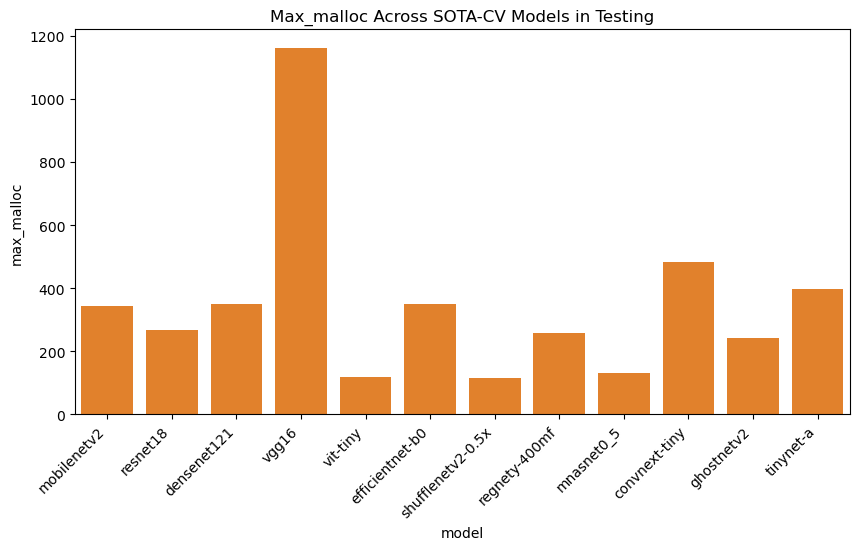

In [21]:
df = dfs_all_testing
mode = "testing"
for metric in dfs_all_testing.columns[:-1]:
        plt.figure(figsize=(10, 5))
        for model in models:
            # Plot the metric
            sns.barplot(x="model", y=metric, data=df, errorbar="sd")
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{metric.capitalize()} Across SOTA-CV Models in {mode.capitalize()}")
        plt.show()

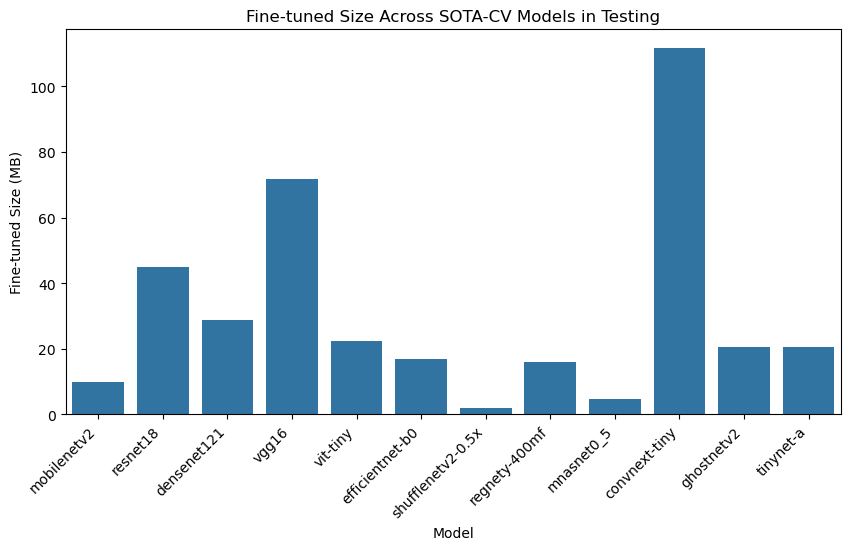

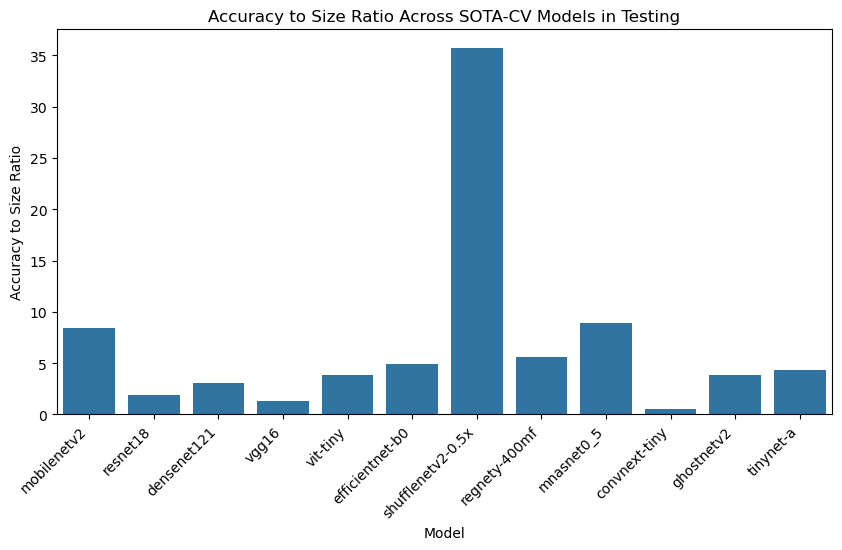

In [22]:
fine_tuned_size = {
    "mobilenetv2": 9.79,
    "resnet18": 45.05, 
    "densenet121": 28.91, 
    "vgg16": 71.72, 
    "vit-tiny": 22.25,
    "efficientnet-b0": 16.97, 
    "shufflenetv2-0.5x": 2.03, 
    "regnety-400mf": 16.08,
    "mnasnet0_5": 4.59, 
    "convnext-tiny": 111.73, 
    "ghostnetv2": 20.66, 
    "tinynet-a": 20.63
}

df_finetuned_size = pd.DataFrame(list(fine_tuned_size.items()), columns=["Model", "Fine-tuned Size (MB)"])

df_finetuned_size["Accuracy"] = dfs_all_testing["accuracy"]

for i, row in df_finetuned_size.iterrows():
    ratio = row["Accuracy"]/row["Fine-tuned Size (MB)"]*100

    df_finetuned_size.loc[i, "Accuracy to Size Ratio"] = ratio
df_finetuned_size

# Create bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Fine-tuned Size (MB)", data=df_finetuned_size)

# Formatting
plt.xticks(rotation=45, ha='right')
plt.title(f"Fine-tuned Size Across SOTA-CV Models in {mode.capitalize()}")

plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="Accuracy to Size Ratio", data=df_finetuned_size)

# Formatting
plt.xticks(rotation=45, ha='right')
plt.title(f"Accuracy to Size Ratio Across SOTA-CV Models in {mode.capitalize()}")

plt.show()